# 02 — Feature Engineering

Turning cleaned appointments into model-ready features. Two principles:

1. **No target leakage** — every historical rate (patient, clinic, provider)
   is computed only from appointments that happened *before* the appointment
   being scored, using a shifted expanding window.
2. **Operational availability** — every feature must exist at scoring time
   for a future appointment (nothing derived from the visit outcome).

The production implementation lives in `etl/feature_engineering.py`; this
notebook walks through the logic and sanity-checks the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 40)
feats = pd.read_csv("../data/processed/appointments_features.csv",
                    parse_dates=["appointment_datetime", "scheduled_datetime"])
print(f"Historical feature rows: {len(feats):,}")
feats.head(3)

Historical feature rows: 32,000


,patient_id,appointment_id,gender,scheduled_datetime,appointment_datetime,age,neighborhood,scholarship_flag,hypertension_flag,diabetes_flag,alcoholism_flag,handicap_flag,sms_received,no_show_flag,lead_time_days,appointment_day_of_week,scheduled_day_of_week,appointment_month,is_weekend,clinic_id,provider_id,specialty,appointment_hour,appointment_type,appointment_status,reminder_count,last_reminder_hours_before_appt,patient_previous_appointments,patient_previous_no_shows,patient_no_show_rate,clinic_no_show_rate,provider_no_show_rate
0,42697530410,5605068,F,2025-09-10 10:35:15,2025-09-12 08:00:00,21,TABUAZEIRO,False,False,False,False,0,False,1,2,Friday,Wednesday,9,False,5,27,Obstetrics & Gynecology,8,Follow-up,No-Show,0,NaN,0,0,0.1994,0.1994,0.1994
1,12798198405,5611940,F,2025-08-30 10:44:45,2025-09-12 08:00:00,49,MARIA ORTIZ,True,True,False,False,0,True,0,13,Friday,Saturday,9,False,6,34,Dermatology,8,Follow-up,Completed,1,24.0,0,0,0.1994,0.1994,0.1994
2,41533897045,5617182,M,2025-09-10 12:26:56,2025-09-12 08:00:00,16,GURIGICA,False,False,False,False,0,False,0,2,Friday,Wednesday,9,False,1,2,Internal Medicine,8,Annual Physical,Completed,0,NaN,0,0,0.1994,0.1994,0.1994


## Engineered feature groups

In [2]:
groups = {
    "Timing": ["lead_time_days", "appointment_day_of_week", "scheduled_day_of_week",
               "appointment_month", "appointment_hour", "is_weekend"],
    "Patient history (leakage-safe)": ["patient_previous_appointments",
        "patient_previous_no_shows", "patient_no_show_rate"],
    "Site history (leakage-safe)": ["clinic_no_show_rate", "provider_no_show_rate"],
    "Reminders": ["reminder_count", "last_reminder_hours_before_appt", "sms_received"],
    "Visit context": ["appointment_type", "specialty", "clinic_id", "provider_id"],
}
for g, cols in groups.items():
    present = [c for c in cols if c in feats.columns]
    print(f"{g:<32} {present}")

Timing                           ['lead_time_days', 'appointment_day_of_week', 'scheduled_day_of_week', 'appointment_month', 'appointment_hour', 'is_weekend']
Patient history (leakage-safe)   ['patient_previous_appointments', 'patient_previous_no_shows', 'patient_no_show_rate']
Site history (leakage-safe)      ['clinic_no_show_rate', 'provider_no_show_rate']
Reminders                        ['reminder_count', 'last_reminder_hours_before_appt', 'sms_received']
Visit context                    ['appointment_type', 'specialty', 'clinic_id', 'provider_id']


## Leakage check: patient history is strictly "prior visits only"

For each appointment, `patient_previous_appointments` counts earlier visits and
`patient_previous_no_shows` counts earlier misses. The first visit of every
patient must therefore have zero prior appointments.

In [3]:
first_visits = feats.sort_values(["appointment_datetime", "appointment_id"]) \
                    .groupby("patient_id").head(1)
assert (first_visits["patient_previous_appointments"] == 0).all()
print(f"OK — all {len(first_visits):,} first visits have zero prior history.")

sample_patient = feats[feats["patient_previous_appointments"] >= 4]["patient_id"].iloc[0]
cols = ["appointment_datetime", "patient_previous_appointments",
        "patient_previous_no_shows", "patient_no_show_rate", "no_show_flag"]
feats[feats["patient_id"] == sample_patient][cols].head(8)

OK — all 5,695 first visits have zero prior history.


,appointment_datetime,patient_previous_appointments,patient_previous_no_shows,patient_no_show_rate,no_show_flag
494,2025-09-16 11:00:00,0,0,0.1994,1
639,2025-09-17 14:30:00,1,1,1.0000,0
693,2025-09-18 09:00:00,2,1,0.5000,0
707,2025-09-18 10:30:00,3,1,0.3333,1
1100,2025-09-22 15:30:00,4,2,0.5000,0
1232,2025-09-23 16:00:00,5,2,0.4000,1
1924,2025-09-30 16:00:00,6,3,0.5000,0
3426,2025-10-14 12:30:00,7,3,0.4286,0


## Does prior behavior predict future behavior?

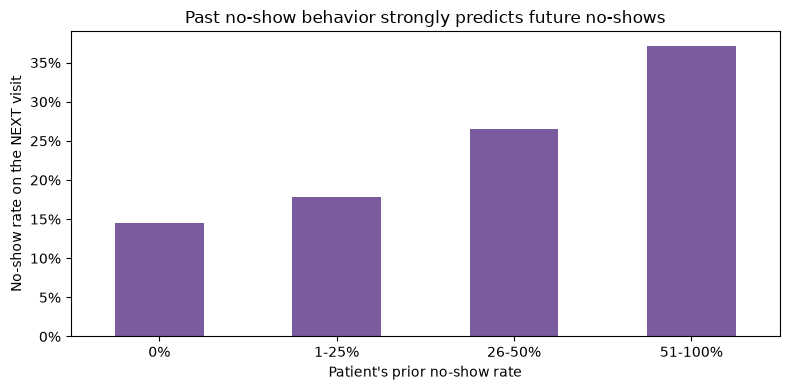

,future_no_show_rate,appointments
prior_rate_bucket,,
0%,0.144431,12982
1-25%,0.177839,5415
26-50%,0.265434,5248
51-100%,0.371429,2660


In [4]:
tmp = feats[feats["patient_previous_appointments"] > 0].copy()
tmp["prior_rate_bucket"] = pd.cut(tmp["patient_no_show_rate"],
                                  [-0.01, 0.0, 0.25, 0.5, 1.0],
                                  labels=["0%", "1-25%", "26-50%", "51-100%"])
by_prior = tmp.groupby("prior_rate_bucket", observed=True)["no_show_flag"].agg(["mean", "count"])
by_prior.columns = ["future_no_show_rate", "appointments"]

fig, ax = plt.subplots(figsize=(8, 4))
by_prior["future_no_show_rate"].plot(kind="bar", ax=ax, color="#7A5C9E")
ax.set_ylabel("No-show rate on the NEXT visit")
ax.set_xlabel("Patient's prior no-show rate")
ax.set_title("Past no-show behavior strongly predicts future no-shows")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
by_prior

## Smoothed site-level rates

In [5]:
print(feats[["clinic_no_show_rate", "provider_no_show_rate"]].describe().round(3))

       clinic_no_show_rate  provider_no_show_rate
count            32000.000              32000.000
mean                 0.203                  0.202
std                  0.037                  0.041
min                  0.092                  0.089
25%                  0.196                  0.189
50%                  0.203                  0.202
75%                  0.207                  0.214
max                  0.323                  0.389


Clinic and provider rates use an expanding window with 20 pseudo-observations
of smoothing so a provider's first weeks aren't dominated by tiny samples.

## Output

Two model-ready files:

- `data/processed/appointments_features.csv` — historical visits with known
  outcomes (model training)
- `data/processed/upcoming_features.csv` — scheduled visits with the same
  columns (production scoring)